Project Title:

Superstore Sales Analysis

Project:

Superstore Sales Analysis Using Python

Business Problem:

The retail company wants to analyze its sales performance to identify factors affecting sales and profit. The objective is to understand customer purchasing behavior, evaluate product performance, and provide insights that help improve profitability and business growth.

Business Objectives:

Analyze overall sales and profit performance.

Identify the most profitable product categories and sub-categories.

Evaluate regional and state-wise sales performance.

Analyze customer segments and shipping modes.

Understand the impact of discounts on profit.

Provide business recommendations to improve sales and profitability.

Data Exploration:

The following table describes the features available in the Superstore Sales dataset.

Row ID: Unique identifier for each order.

Order ID: Unique identifier assigned to each customer order.

Order Date: Date on which the order was placed.

Ship Date: Date on which the order was shipped.

Ship Mode: Shipping method used for delivery.

Customer ID: Unique identifier assigned to each customer.

Customer Name: Name of the customer.

Segment: Customer segment (Consumer, Corporate, Home Office).

Country: Country where the order was placed.

City: Customer's city.

State: Customer's state.

Postal Code: Postal code of the customer.

Region: Sales region (East, West, Central, South).

Product ID: Unique identifier for each product.

Category: Product category (Furniture, Office Supplies, Technology).

Sub-Category: Product sub-category.

Product Name: Name of the product.

Sales: Revenue generated from the order.

Quantity: Number of products sold.

Discount: Discount applied to the order.

Profit: Profit earned from the order.

Business Questions:

What is the total sales and total profit?

Which product category generates the highest sales?

Which sub-category generates the highest profit?

Which region contributes the highest sales?

Which state generates the highest revenue?

Which customer segment is the most profitable?

Does offering higher discounts reduce profit?

Which shipping mode is used the most?

Which products generate losses?

What are the top 10 products by sales?

Which regions have the highest and lowest profits?

What is the monthly sales trend?

What is the monthly profit trend?

Which customers contribute the highest sales?

Which products should the business focus on to maximize profit?

In [10]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [8]:
df=pd.read_csv('Superstore_Analysis.csv', encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [11]:
#Data set shape
df.shape

(9994, 21)

In [12]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
#column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [15]:
#Datatypes
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [16]:
#summary for statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


DATA CLEANING:


In [17]:
#checking missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [18]:
#checking duplicated values
df.duplicated().sum()

np.int64(0)

In [22]:
#converting data types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [23]:
#verify data types
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [26]:
#Feature Engineering
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [27]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,January,1,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,February,1,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,February,1,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,February,1,5


Univariate Analysis


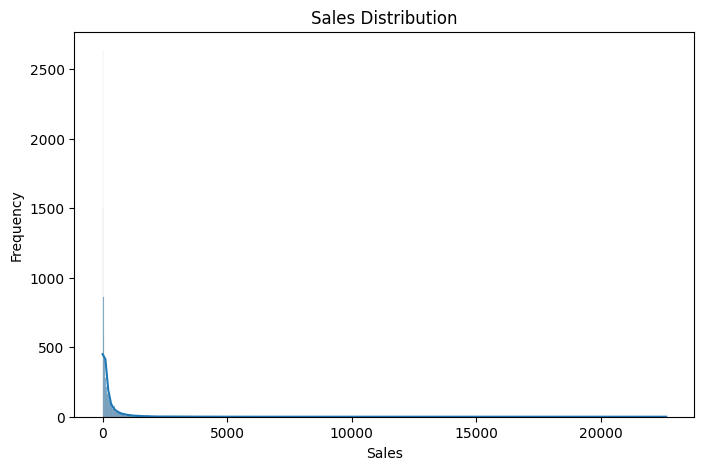

In [28]:
#sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

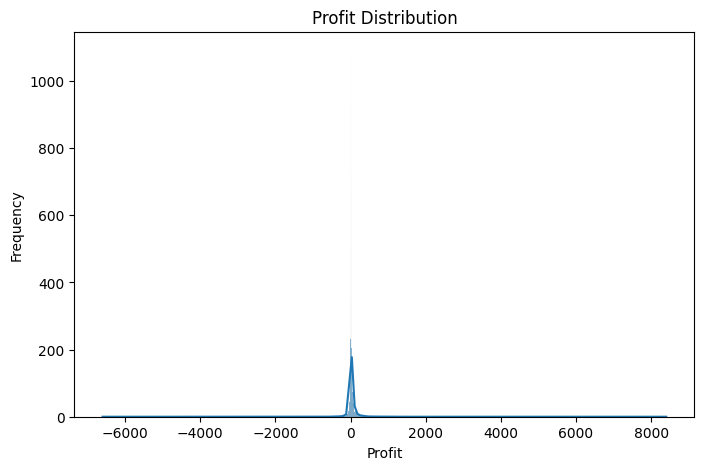

In [29]:
#profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

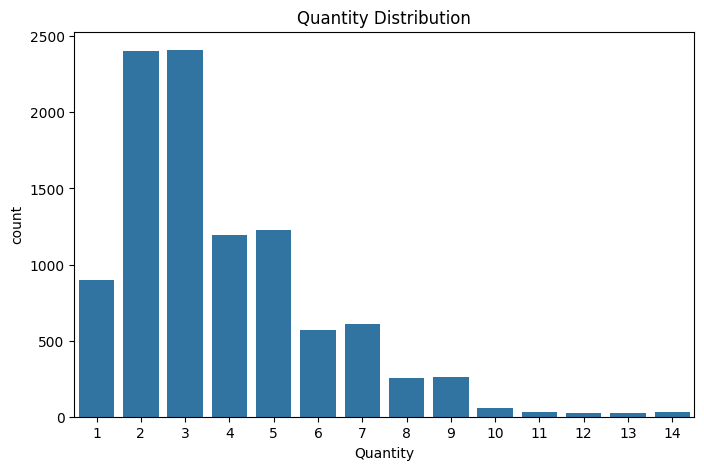

In [30]:
#Quantity distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Quantity')
plt.title("Quantity Distribution")
plt.show()

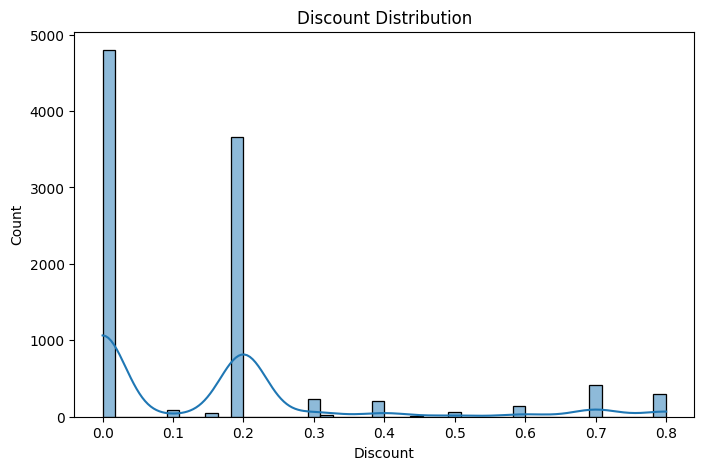

In [31]:
#Discount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Discount'], kde=True)
plt.title("Discount Distribution")
plt.show()

Bi variate Analysis


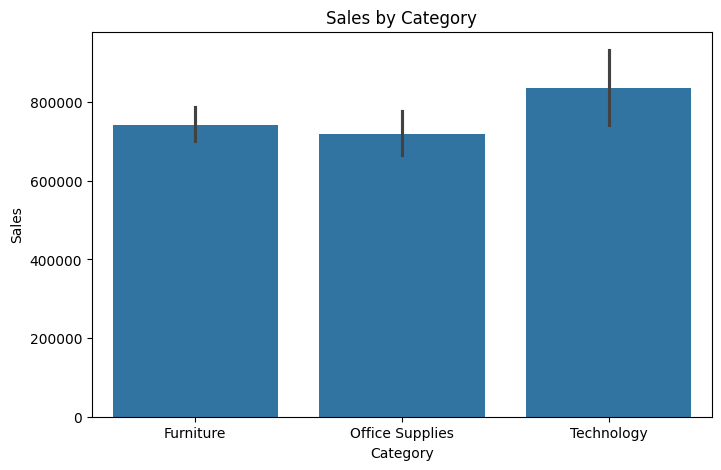

In [32]:
#sales by category
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum)

plt.title("Sales by Category")
plt.show()

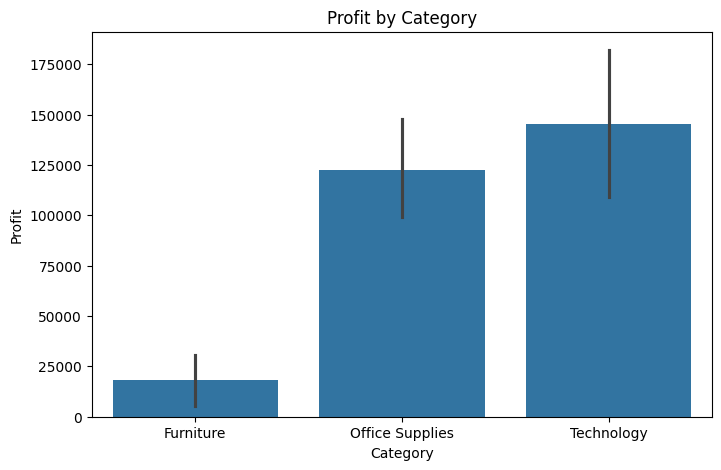

In [33]:
#profit by category
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Profit', estimator=sum)

plt.title("Profit by Category")
plt.show()

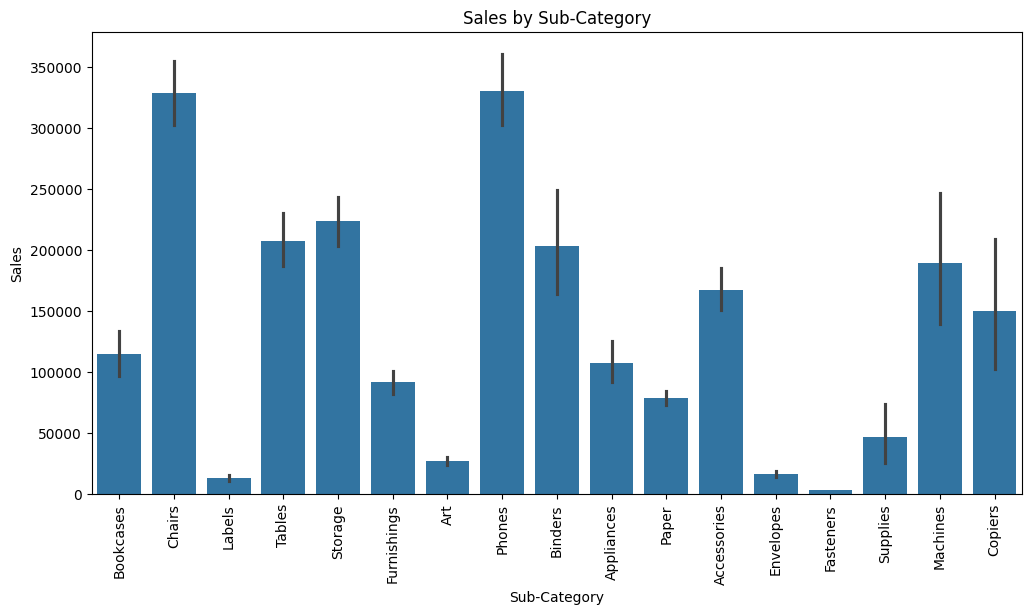

In [34]:
#sales by sub-category
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Sub-Category', y='Sales', estimator=sum)

plt.xticks(rotation=90)
plt.title("Sales by Sub-Category")
plt.show()

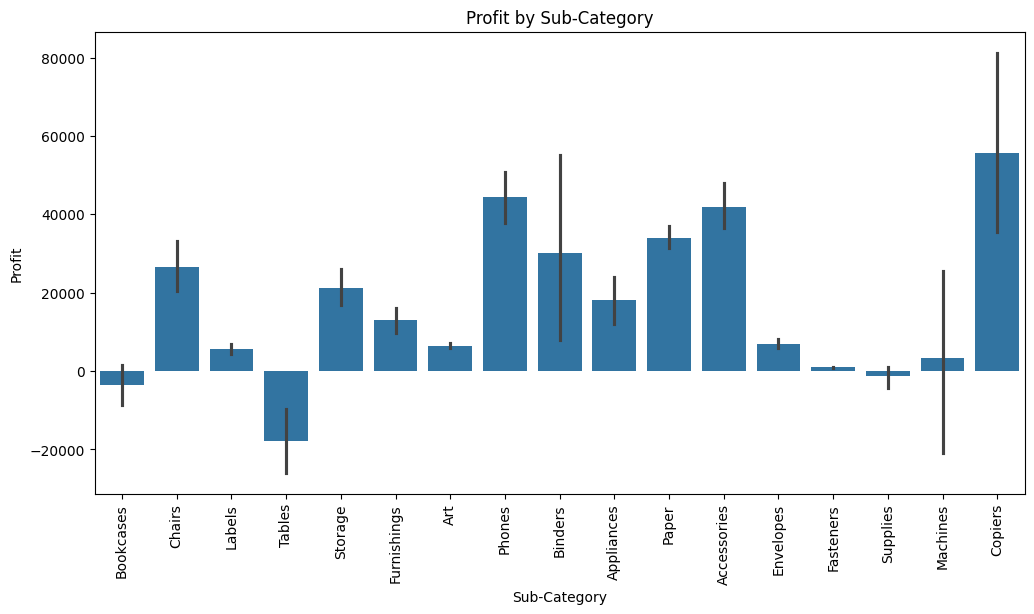

In [35]:
#profit by subcategory
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Sub-Category', y='Profit', estimator=sum)

plt.xticks(rotation=90)
plt.title("Profit by Sub-Category")
plt.show()

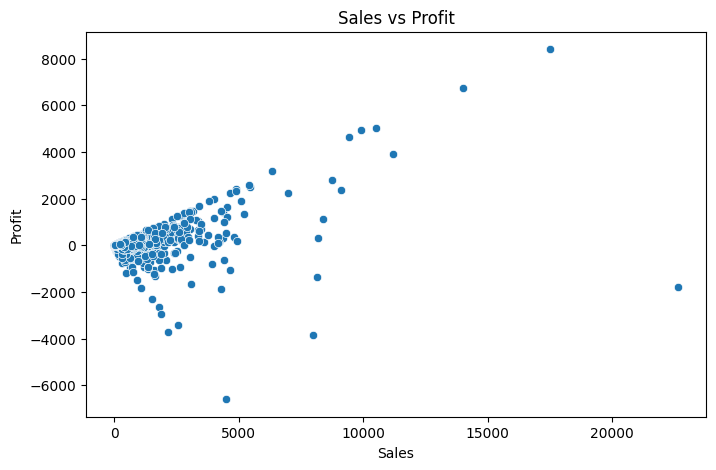

In [36]:
#sales vs profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')

plt.title("Sales vs Profit")
plt.show()

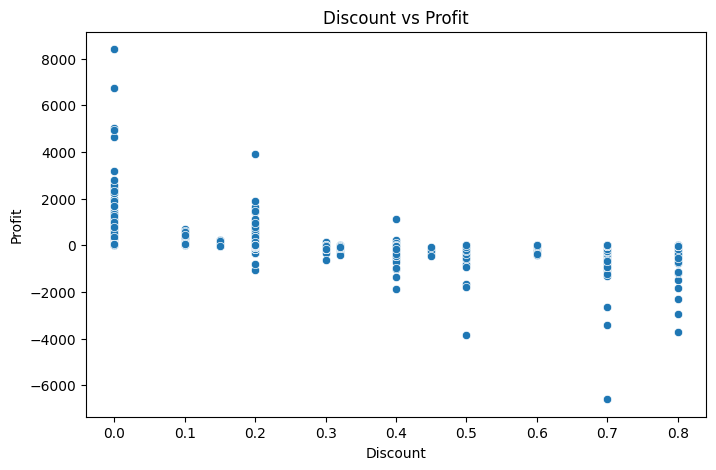

In [37]:
#Discount vs profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title("Discount vs Profit")
plt.show()

Multivariate Analysis


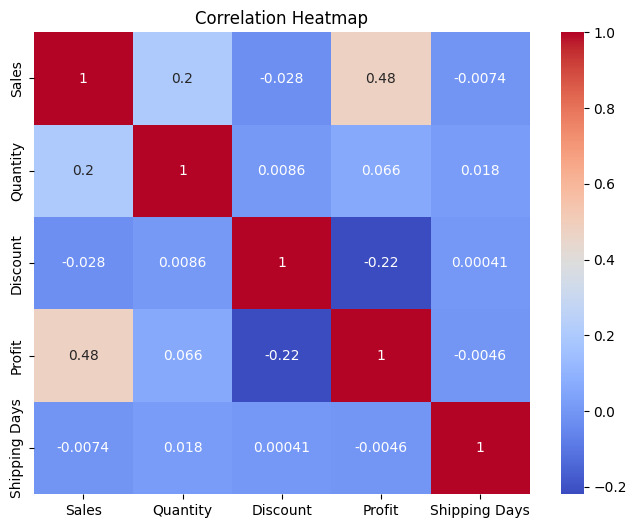

In [38]:
#correlation
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit','Shipping Days']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

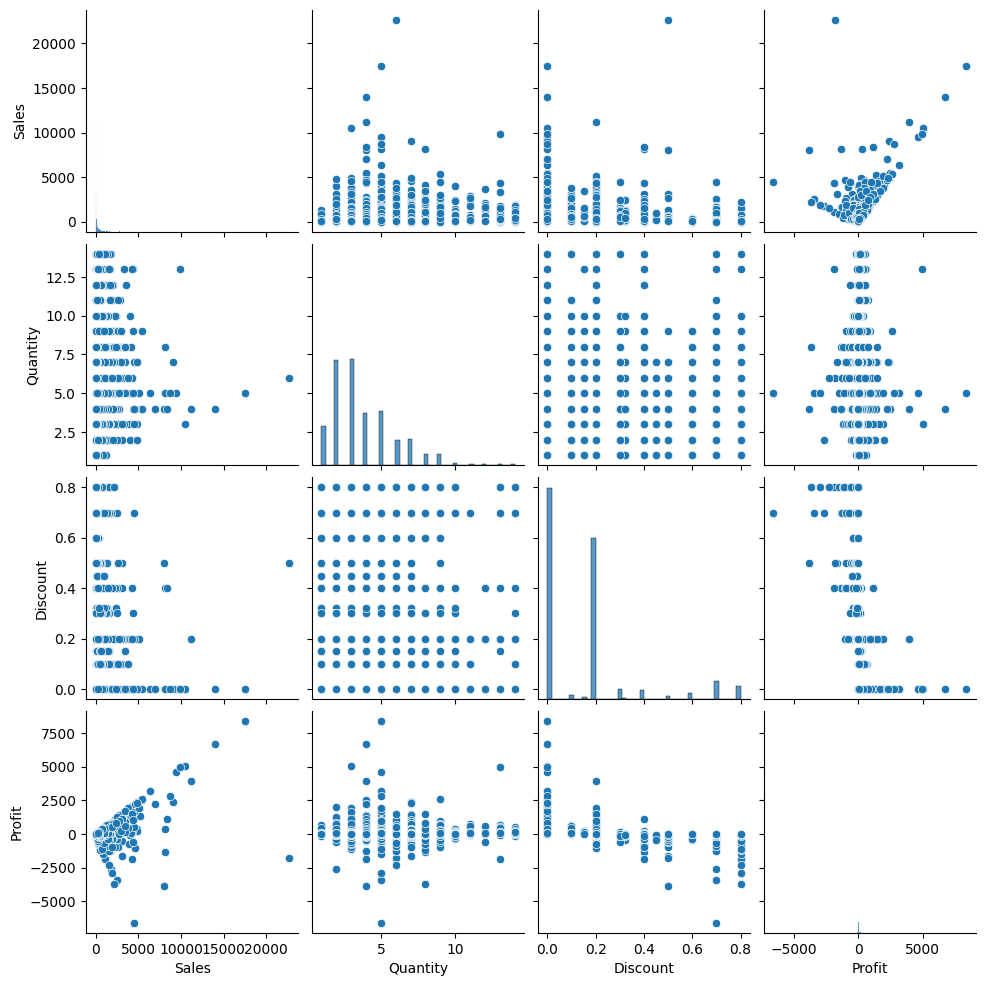

In [39]:
#pairplot
sns.pairplot(
    df[['Sales','Quantity','Discount','Profit']]
)

plt.show()

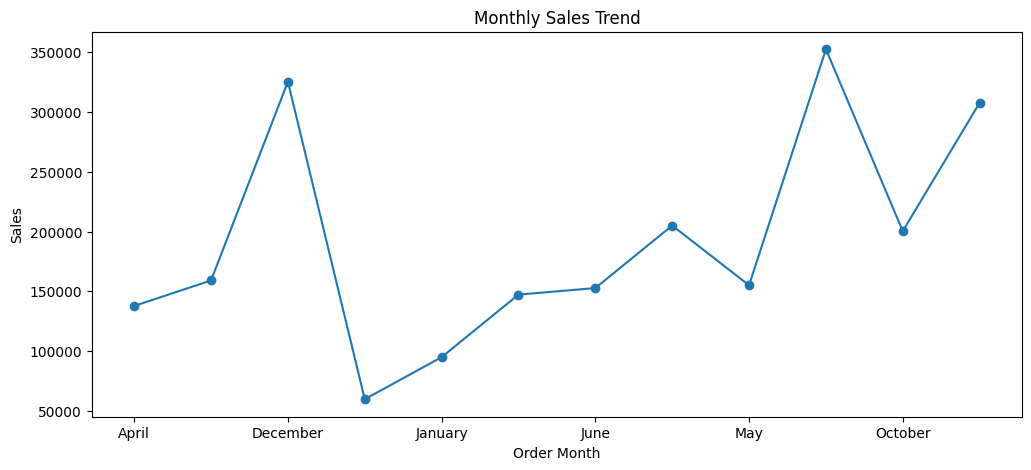

In [40]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

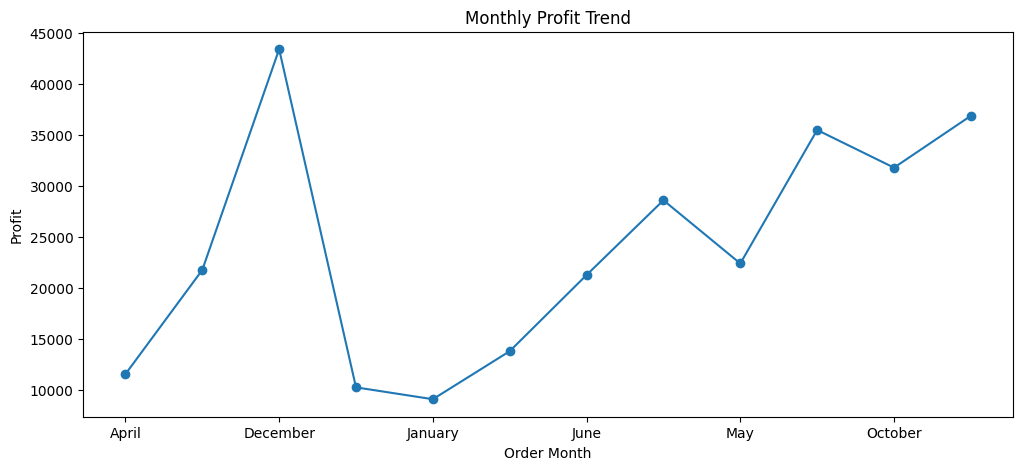

In [41]:
monthly_profit = df.groupby('Order Month')['Profit'].sum()

plt.figure(figsize=(12,5))

monthly_profit.plot(marker='o')

plt.title("Monthly Profit Trend")
plt.ylabel("Profit")
plt.show()

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


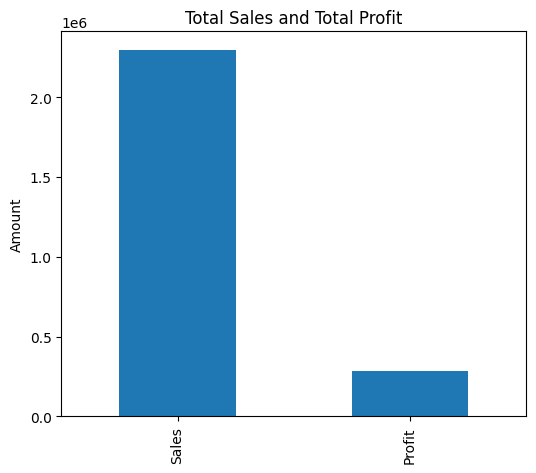

In [49]:
#1. What are the total sales and total profit?


print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())


sales_profit = df[['Sales','Profit']].sum()

sales_profit.plot(kind='bar', figsize=(6,5))

plt.title("Total Sales and Total Profit")
plt.ylabel("Amount")
plt.show()

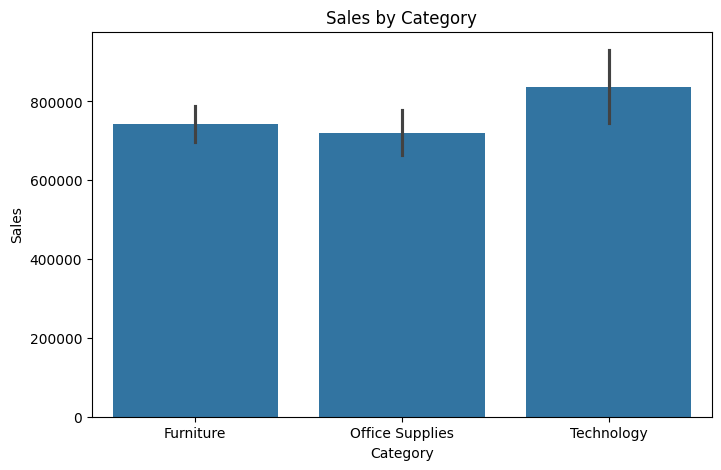

In [42]:
#2. Which product category generates the highest sales?

df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Category',
    y='Sales',
    estimator=sum
)

plt.title("Sales by Category")
plt.show()

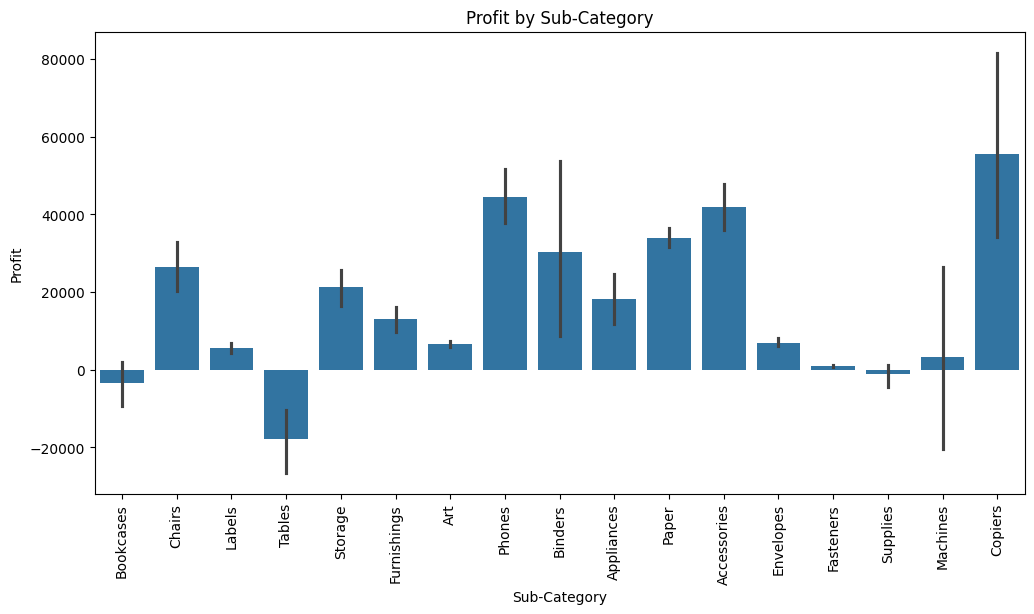

In [43]:
#3. Which sub-category generates the highest profit?

df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)


plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Sub-Category',
    y='Profit',
    estimator=sum
)

plt.xticks(rotation=90)
plt.title("Profit by Sub-Category")
plt.show()

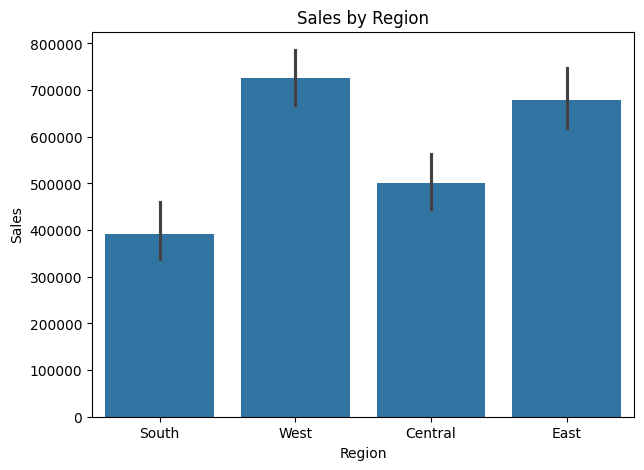

In [44]:
#4. Which region contributes the highest sales?

df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='Region',
    y='Sales',
    estimator=sum
)

plt.title("Sales by Region")
plt.show()

In [ ]:
#5. Which state generates the highest revenue?


df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)


top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

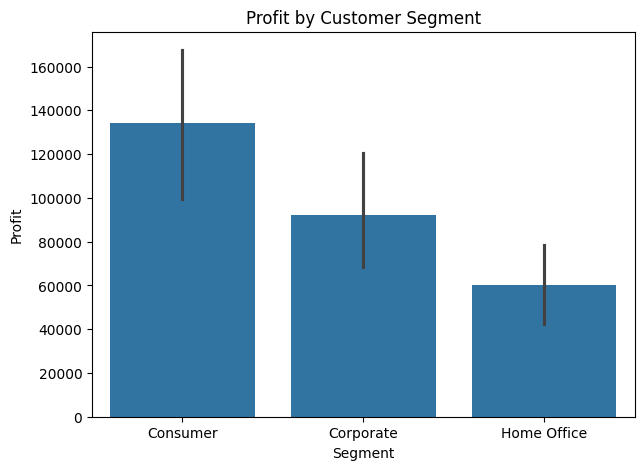

In [45]:
#6. Which customer segment is the most profitable?



df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='Segment',
    y='Profit',
    estimator=sum
)

plt.title("Profit by Customer Segment")
plt.show()

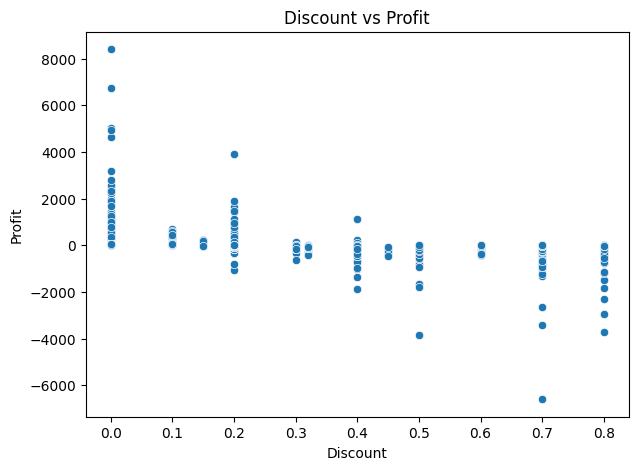

In [46]:
#7. Does offering higher discounts reduce profit?


df[['Discount','Profit']].corr()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit")
plt.show()

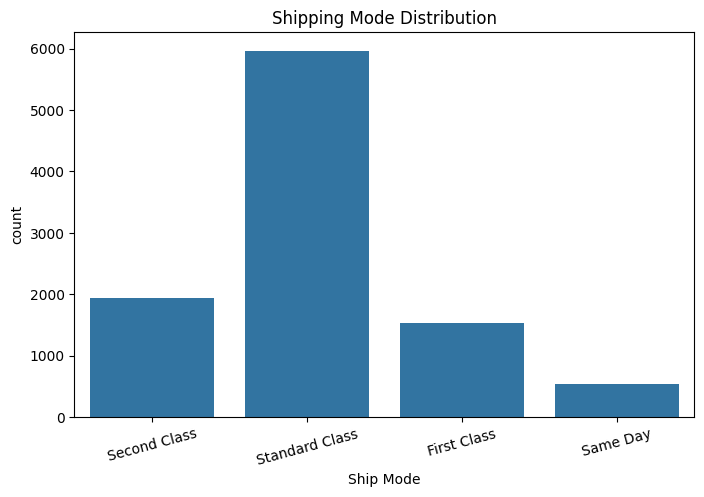

In [47]:
#8. Which shipping mode is used the most?



df['Ship Mode'].value_counts()

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Ship Mode'
)

plt.xticks(rotation=15)

plt.title("Shipping Mode Distribution")
plt.show()

In [ ]:
#9. Which products generate losses?


df.groupby('Product Name')['Profit'].sum().sort_values().head(10)


loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

loss_products.plot(kind='bar', figsize=(12,5), color='red')

plt.title("Top 10 Loss Making Products")
plt.ylabel("Profit")
plt.show()

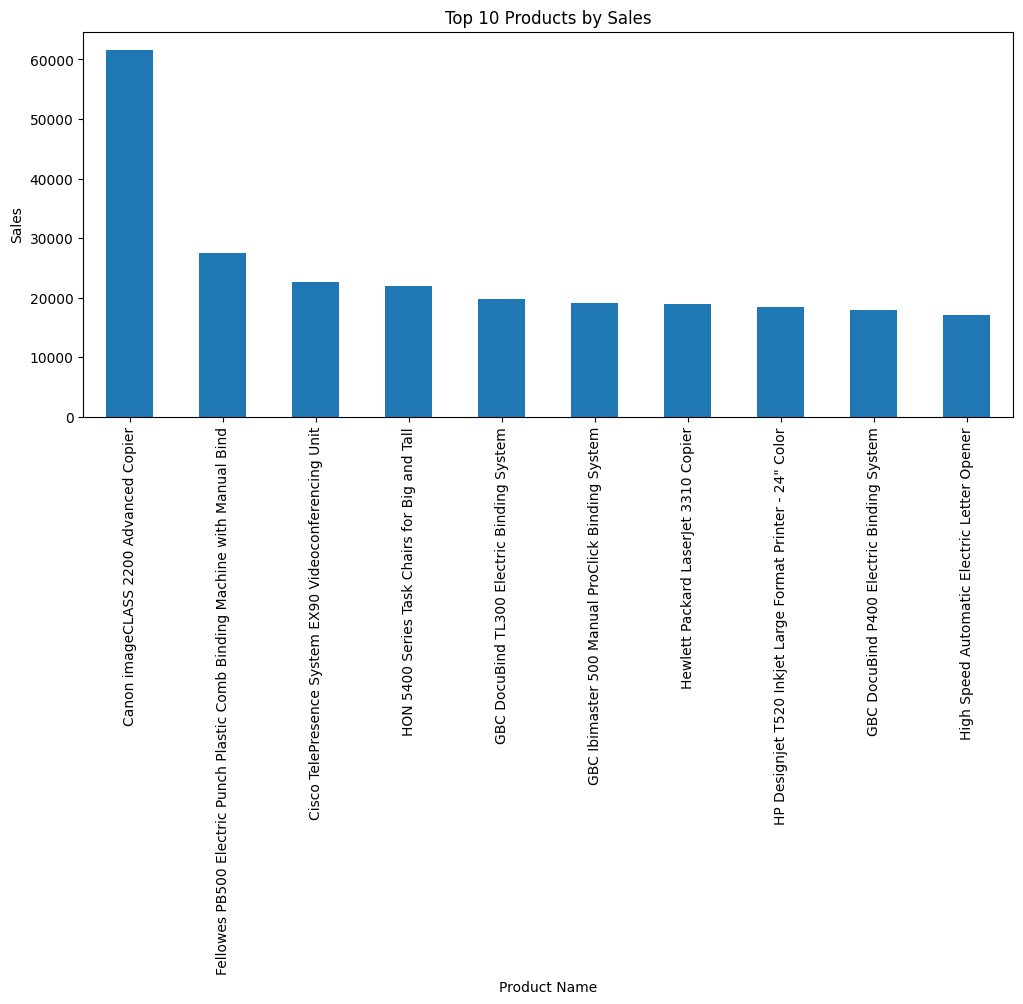

In [48]:
#10. What are the top 10 products by sales?



df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)


top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(12,5))

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

In [80]:


# Define target variable y
X = df[["Discount","Quantity"]]
y = df["Sales"]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = model.predict([[0.5,4]])
y_pred[0]

np.float64(193.54175777519063)

In [74]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 286.23479598238276
MSE : 592714.1808779107
RMSE: 769.8793287768615
R² Score: -0.003411242471438536


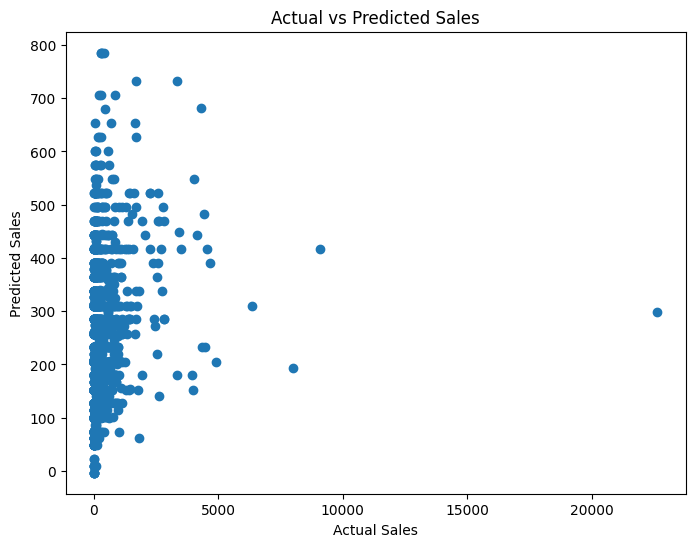

In [86]:
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Insights:
Sales vary significantly across orders, with a few high-value transactions contributing a large share of total revenue.

Higher quantities generally lead to higher sales, making Quantity an important predictor of Sales.

Discounts do not always increase Sales. In many cases, larger discounts reduce revenue and can negatively affect profitability.

Product categories and sub-categories contribute differently to overall sales, indicating that some products consistently outperform others.

Regional sales performance differs, suggesting opportunities to strengthen marketing and inventory planning in lower-performing regions.


Conclusion:
The Superstore analysis identified the key factors influencing Sales.
Quantity has a positive impact on Sales, while Discount should be used strategically because excessive discounts may reduce overall business performance.

The Linear Regression model demonstrates how historical data can be used to predict future Sales and support business decision-making.

The insights from EDA and the predictive model can help management optimize pricing strategies, improve inventory planning, and focus on high-performing products and regions.

In [87]:
df.to_csv("Superstore.Analysis.csv")